In [3]:
!pip install optuna

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import optuna

# Generate dataset (Gym data)
np.random.seed(42)
data_size = 500

# Inputs: workout, calories, sleep, intensity
X = np.random.rand(data_size, 4)

# Outputs: weight change, muscle gain, fat %
y = np.random.rand(data_size, 3)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
def create_model(trial):
    model = tf.keras.Sequential()

    n_layers = trial.suggest_int("layers", 1, 3)

    for i in range(n_layers):
        model.add(tf.keras.layers.Dense(
            trial.suggest_int(f"units_{i}", 16, 128),
            activation='relu'
        ))

    model.add(tf.keras.layers.Dense(3))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            trial.suggest_float("lr", 1e-4, 1e-2)
        ),
        loss='mse'
    )

    return model

# Optuna
def objective(trial):
    model = create_model(trial)
    model.fit(X_train, y_train, epochs=20, verbose=0)
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best Parameters:", study.best_params)

[I 2026-03-23 04:38:00,514] A new study created in memory with name: no-name-b09fc56a-1233-4a79-b942-5ea2e5537eb8
[I 2026-03-23 04:38:04,590] Trial 0 finished with value: 0.09469980001449585 and parameters: {'layers': 1, 'units_0': 114, 'lr': 0.003386430592511651}. Best is trial 0 with value: 0.09469980001449585.
[I 2026-03-23 04:38:12,456] Trial 1 finished with value: 0.10042132437229156 and parameters: {'layers': 2, 'units_0': 19, 'units_1': 91, 'lr': 0.00528734669423342}. Best is trial 0 with value: 0.09469980001449585.
[I 2026-03-23 04:38:19,084] Trial 2 finished with value: 0.09990552812814713 and parameters: {'layers': 2, 'units_0': 102, 'units_1': 57, 'lr': 0.005800574191008617}. Best is trial 0 with value: 0.09469980001449585.
[I 2026-03-23 04:38:22,757] Trial 3 finished with value: 0.10625843703746796 and parameters: {'layers': 3, 'units_0': 31, 'units_1': 27, 'units_2': 112, 'lr': 0.008566318713891581}. Best is trial 0 with value: 0.09469980001449585.
[I 2026-03-23 04:38:25,5

Best Parameters: {'layers': 1, 'units_0': 114, 'lr': 0.003386430592511651}


In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)
data_size = 500

# Inputs
workout = np.random.randint(30, 120, data_size)        # minutes
calories = np.random.randint(1800, 3000, data_size)    # kcal
sleep = np.random.uniform(5, 9, data_size)             # hours
intensity = np.random.randint(5, 10, data_size)        # scale 1–10

# Outputs (realistic relationships)
weight_change = (-0.02 * workout) + (0.001 * calories) - (0.3 * intensity) + np.random.normal(0, 0.5, data_size)
muscle_gain = (0.03 * workout) + (0.002 * calories) + (0.5 * intensity) + np.random.normal(0, 0.5, data_size)
fat_loss = (-0.025 * workout) - (0.002 * calories) - (0.4 * intensity) + np.random.normal(0, 0.5, data_size)

# Combine
X = np.column_stack((workout, calories, sleep, intensity))
y = np.column_stack((weight_change, muscle_gain, fat_loss))

# Convert to DataFrame (for visualization)
df = pd.DataFrame(X, columns=["Workout", "Calories", "Sleep", "Intensity"])
df["WeightChange"] = weight_change
df["MuscleGain"] = muscle_gain
df["FatLoss"] = fat_loss

df.head()

,Workout,Calories,Sleep,Intensity,WeightChange,MuscleGain,FatLoss
0,81.0,2196.0,8.647410,6.0,-1.336573,9.432424,-9.028317
1,44.0,1811.0,5.556465,6.0,-0.770211,7.844834,-6.783701
2,101.0,2298.0,5.403178,6.0,-0.289561,10.182890,-9.788980
3,90.0,2553.0,6.024062,6.0,-1.197070,10.940331,-9.485988
4,50.0,1834.0,7.904382,6.0,-1.291207,8.219772,-7.967558


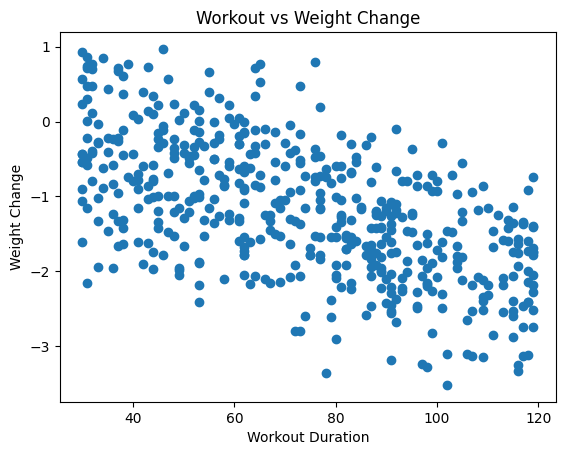

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df["Workout"], df["WeightChange"])
plt.xlabel("Workout Duration")
plt.ylabel("Weight Change")
plt.title("Workout vs Weight Change")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


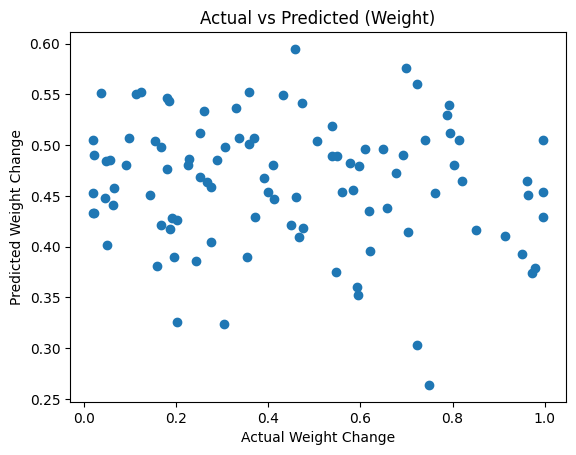

In [7]:
# Predictions
y_pred = study.best_trial.user_attrs.get("model", None)

# Instead manually retrain best model
best_params = study.best_params

model = tf.keras.Sequential()

for i in range(best_params["layers"]):
    model.add(tf.keras.layers.Dense(best_params[f"units_{i}"], activation='relu'))

model.add(tf.keras.layers.Dense(3))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["lr"]),
    loss='mse'
)

model.fit(X_train, y_train, epochs=50, verbose=0)

y_pred = model.predict(X_test)

# Plot actual vs predicted
plt.scatter(y_test[:, 0], y_pred[:, 0])
plt.xlabel("Actual Weight Change")
plt.ylabel("Predicted Weight Change")
plt.title("Actual vs Predicted (Weight)")
plt.show()

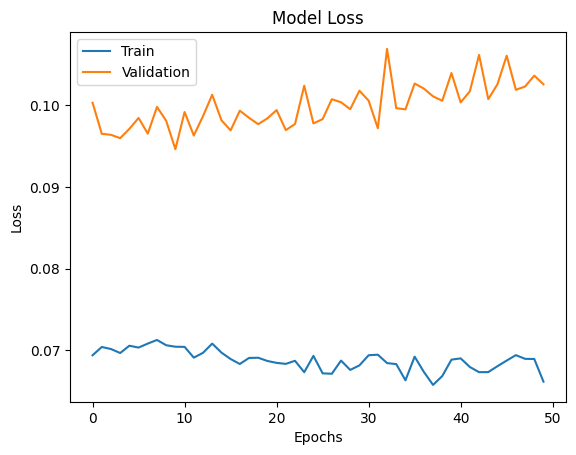

In [8]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()